In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from pathlib import Path

In [2]:
mat_path = Path(
    r"Z:\ResearchHome\SharedResources\CtrBioimageInformatics\common\Anna\Personal\Biohackathon\ahiData-pats-805603-baseline.mat")

mat = loadmat(
    mat_path,
    squeeze_me=True,
    struct_as_record=False
)

print(mat.keys())

dict_keys(['__header__', '__version__', '__globals__', 'study_number', 'file_edf', 'file_event', 'annotate', 'events', 'metrics', 'signals'])


In [3]:
signals = mat["signals"]

print(signals)
print(signals._fieldnames)

['labels', 'data', 'time']


In [4]:
time = np.asarray(signals.time).squeeze()
data = np.asarray(signals.data)

# Occasionally MATLAB/Python orientation can be unexpected.
# We want shape = (timepoints, channels)
if data.shape[0] != len(time) and data.shape[1] == len(time):
    data = data.T

# Convert MATLAB cell-array labels to normal Python strings
labels = [str(x).strip() for x in np.atleast_1d(signals.labels)]

print("Data shape:", data.shape)
print("Time shape:", time.shape)
print("Labels:", labels)

print(f"Recording duration: {time[-1] / 3600:.2f} hours")
print(f"Approx sampling rate: {1 / np.median(np.diff(time)):.2f} Hz")

Data shape: (342540, 7)
Time shape: (342540,)
Labels: ['thorax', 'airFlow', 'SpO2', 'arousalMean', 'aflowBreaths', 'sleepStages', 'OriginalDetections']
Recording duration: 4.76 hours
Approx sampling rate: 20.00 Hz


Detection values: [   0. 1000.]
Number of detected samples: 154


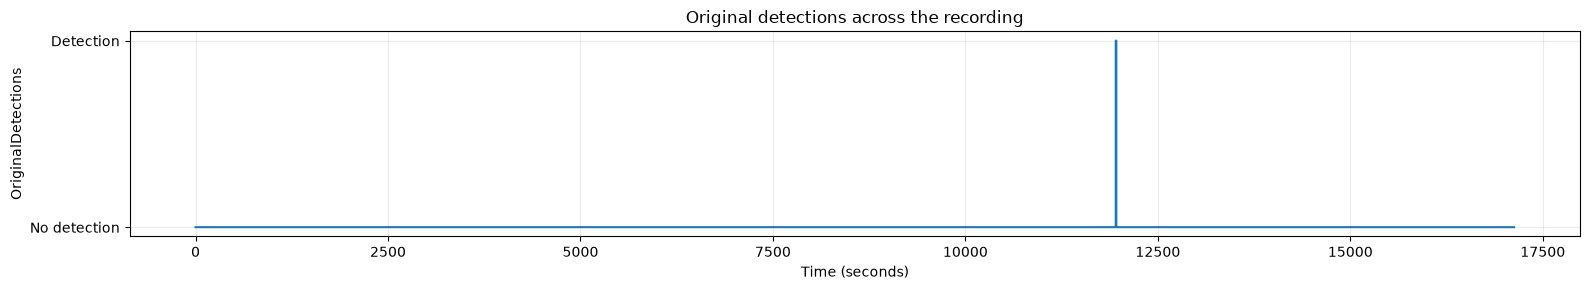

In [ ]:
detection_idx = labels.index("OriginalDetections")
detections = np.asarray(data[:, detection_idx]).squeeze()
event_mask = detections > 0

print("Detection values:", np.unique(detections))
print("Number of detected samples:", event_mask.sum())

plt.figure(figsize=(16, 3))
plt.step(time, event_mask.astype(int), where="post")
plt.yticks([0, 1], ["No detection", "Detection"])
plt.xlabel("Time (seconds)")
plt.ylabel("OriginalDetections")
plt.title("Original detections across the recording")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
def plot_sleep_window(time, data, labels, start_sec=0, duration_sec=300):
    """
    Plot a section of the sleep recording.

    Parameters
    ----------
    time : 1D array
        Time in seconds.
    data : 2D array
        Shape = (samples, channels).
    labels : list of str
        Channel names.
    start_sec : float
        Beginning of window in seconds.
    duration_sec : float
        Length of displayed window in seconds.
    """

    end_sec = start_sec + duration_sec

    mask = (time >= start_sec) & (time <= end_sec)

    t = time[mask]
    x = data[mask, :]

    n_channels = len(labels)

    fig, axes = plt.subplots(
        n_channels,
        1,
        figsize=(16, 2.1 * n_channels),
        sharex=True
    )

    if n_channels == 1:
        axes = [axes]

    for i, (ax, label) in enumerate(zip(axes, labels)):

        y = x[:, i]

        if label == "sleepStages":
            ax.step(t, y, where="post")
            ax.set_yticks([0, 1, 2, 3, 5])
            ax.set_yticklabels(["Wake", "N1", "N2", "N3", "REM"])

        elif label == "OriginalDetections":
            # Report says annotations are stored as 0 or 1000
            event_binary = y > 0

            ax.fill_between(
                t,
                0,
                event_binary.astype(float),
                step="post",
                alpha=0.5
            )

            ax.set_ylim(-0.05, 1.05)
            ax.set_yticks([0, 1])
            ax.set_yticklabels(["Normal", "Event"])

        else:
            ax.plot(t, y, linewidth=1)

        ax.set_ylabel(label)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Time (seconds)")

    fig.suptitle(
        f"Sleep recording: {start_sec:.0f}–{end_sec:.0f} seconds",
        y=1.002
    )

    plt.tight_layout()
    plt.show()

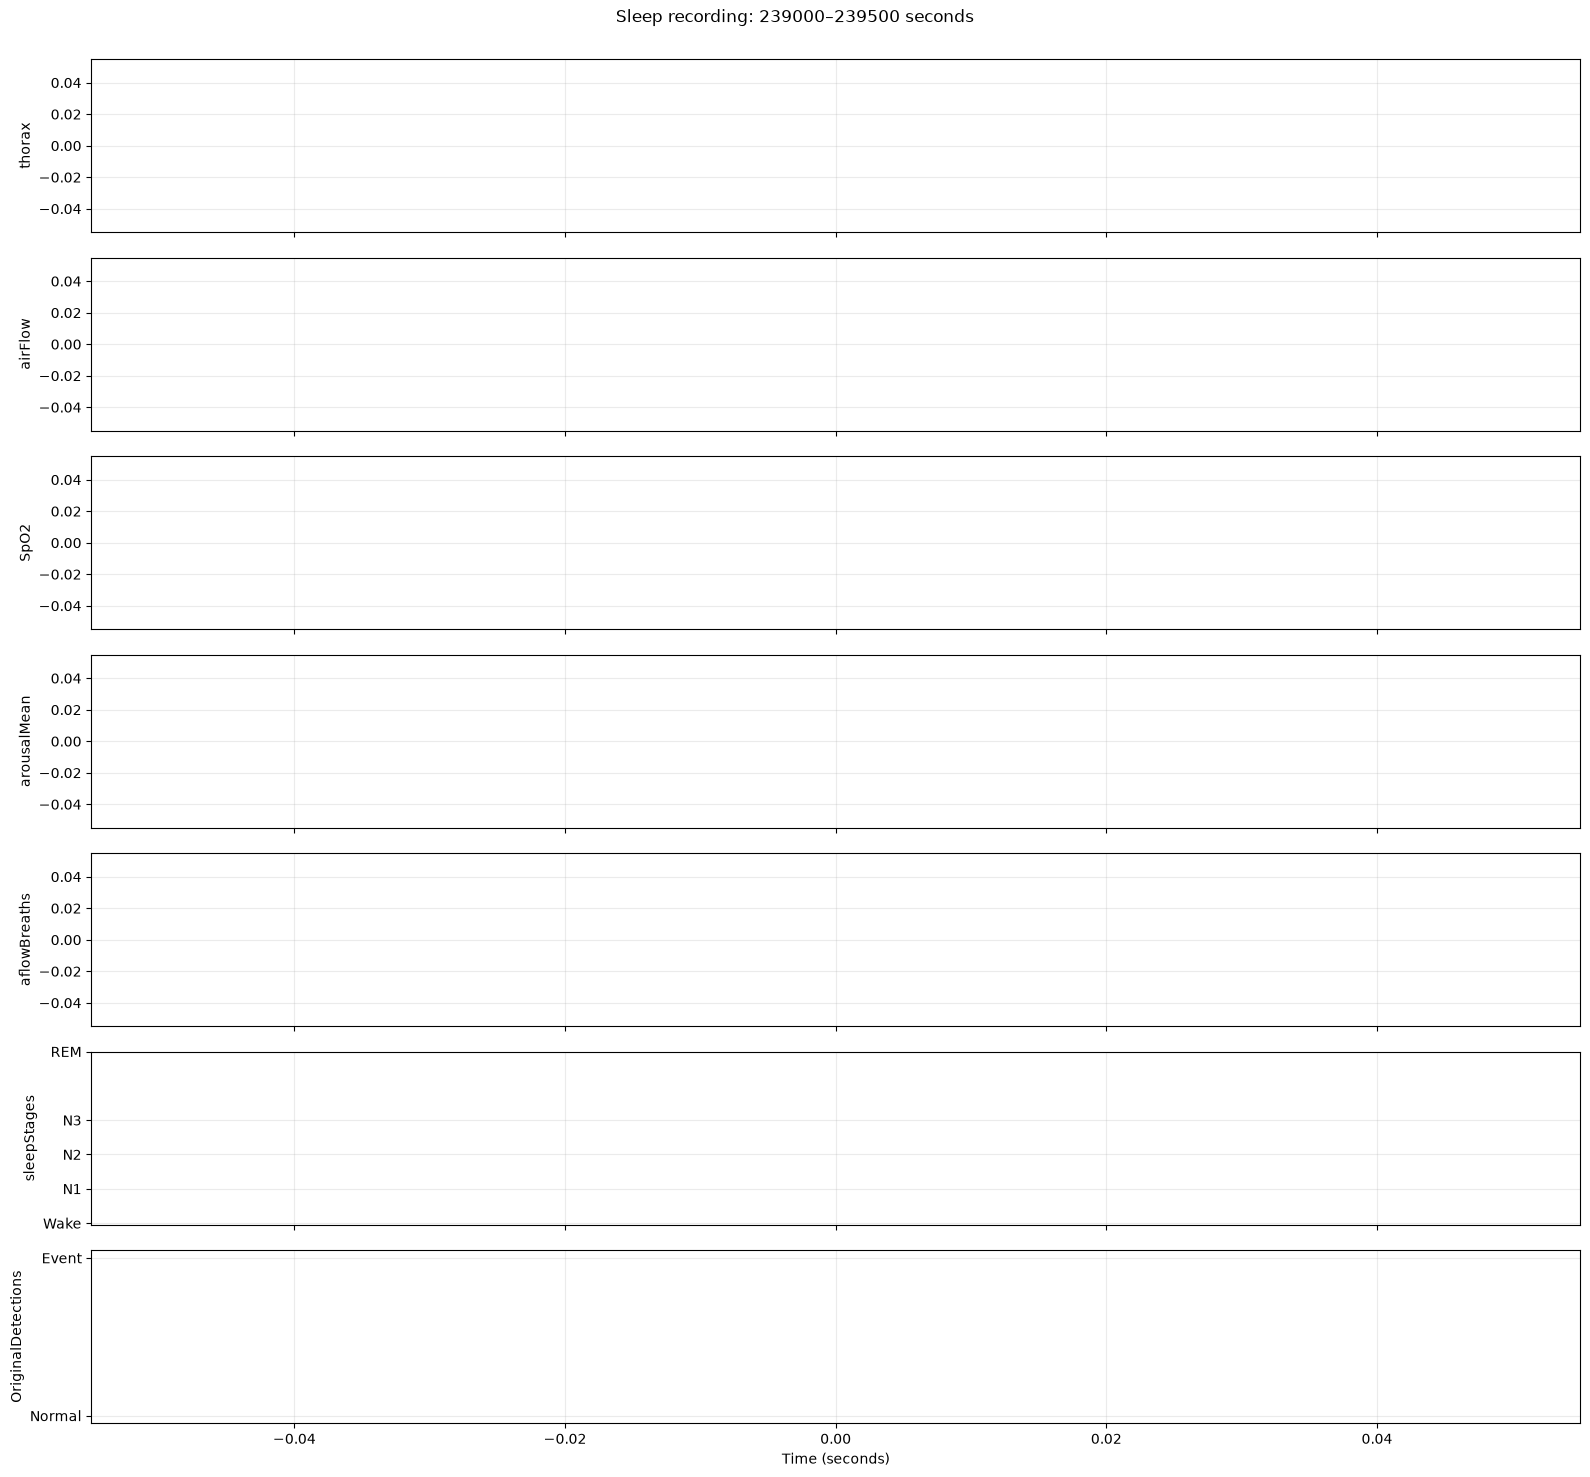

In [ ]:
plot_sleep_window(
    time,
    data,
    labels,
    start_sec= 239000,
    duration_sec=500
)

In [ ]:
events = mat["events"]

print(events._fieldnames)
apneas = np.asarray(events.apneas)
hypopneas = np.asarray(events.hypopneas)

print("Apneas shape:", apneas.shape)
print("Hypopneas shape:", hypopneas.shape)

print("First few apneas:")
print(apneas[:5])

print("First few hypopneas:")
print(hypopneas[:5])

['apneas', 'hypopneas']
Apneas shape: (0,)
Hypopneas shape: (2,)
First few apneas:
[]
First few hypopneas:
[239057 239211]


In [ ]:
def plot_event(
    time,
    data,
    labels,
    event_indices,
    event_number=0,
    padding_sec=30,
    event_name="Event"
):

    event_indices = np.asarray(event_indices).squeeze()

    if event_indices.ndim == 1:
        if event_indices.size != 2:
            raise ValueError(
                f"{event_name} must contain start/end index pairs; "
                f"received shape {event_indices.shape}."
            )
        event_indices = event_indices.reshape(1, 2)

    event_indices = np.atleast_2d(event_indices)
    if event_indices.shape[1] < 2:
        raise ValueError(
            f"{event_name} must contain start/end index pairs; "
            f"received shape {event_indices.shape}."
        )
    if event_number >= len(event_indices):
        raise IndexError(
            f"{event_name} event_number={event_number} is out of bounds; "
            f"there are {len(event_indices)} events."
        )

    # Convert MATLAB 1-based indices to Python 0-based indices.
    start_idx = int(event_indices[event_number, 0]) - 1
    end_idx = int(event_indices[event_number, 1]) - 1

    if not (0 <= start_idx < len(time)) or not (0 <= end_idx < len(time)):
        raise IndexError(
            f"{event_name} indices ({start_idx + 1}, {end_idx + 1}) "
            f"are outside the recording with {len(time)} samples."
        )

    start_time = time[start_idx]
    end_time = time[end_idx]

    window_start = max(time[0], start_time - padding_sec)
    window_end = min(time[-1], end_time + padding_sec)

    mask = (time >= window_start) & (time <= window_end)

    t = time[mask]
    x = data[mask]

    fig, axes = plt.subplots(
        len(labels),
        1,
        figsize=(16, 2.1 * len(labels)),
        sharex=True
    )

    if len(labels) == 1:
        axes = [axes]

    for i, (ax, label) in enumerate(zip(axes, labels)):

        y = x[:, i]

        if label == "sleepStages":
            ax.step(t, y, where="post")
            ax.set_yticks([0, 1, 2, 3, 5])
            ax.set_yticklabels(["Wake", "N1", "N2", "N3", "REM"])

        elif label == "OriginalDetections":
            ax.fill_between(
                t,
                0,
                (y > 0).astype(float),
                step="post",
                alpha=0.5
            )
            ax.set_ylim(-0.05, 1.05)

        else:
            ax.plot(t, y, linewidth=1)

        ax.axvspan(start_time, end_time, alpha=0.15)

        ax.set_ylabel(label)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Time (seconds)")

    fig.suptitle(
        f"{event_name} #{event_number} "
        f"({start_time:.1f}–{end_time:.1f} s, "
        f"{end_time-start_time:.1f} sec)",
        y=1.002
    )

    plt.tight_layout()
    plt.show()

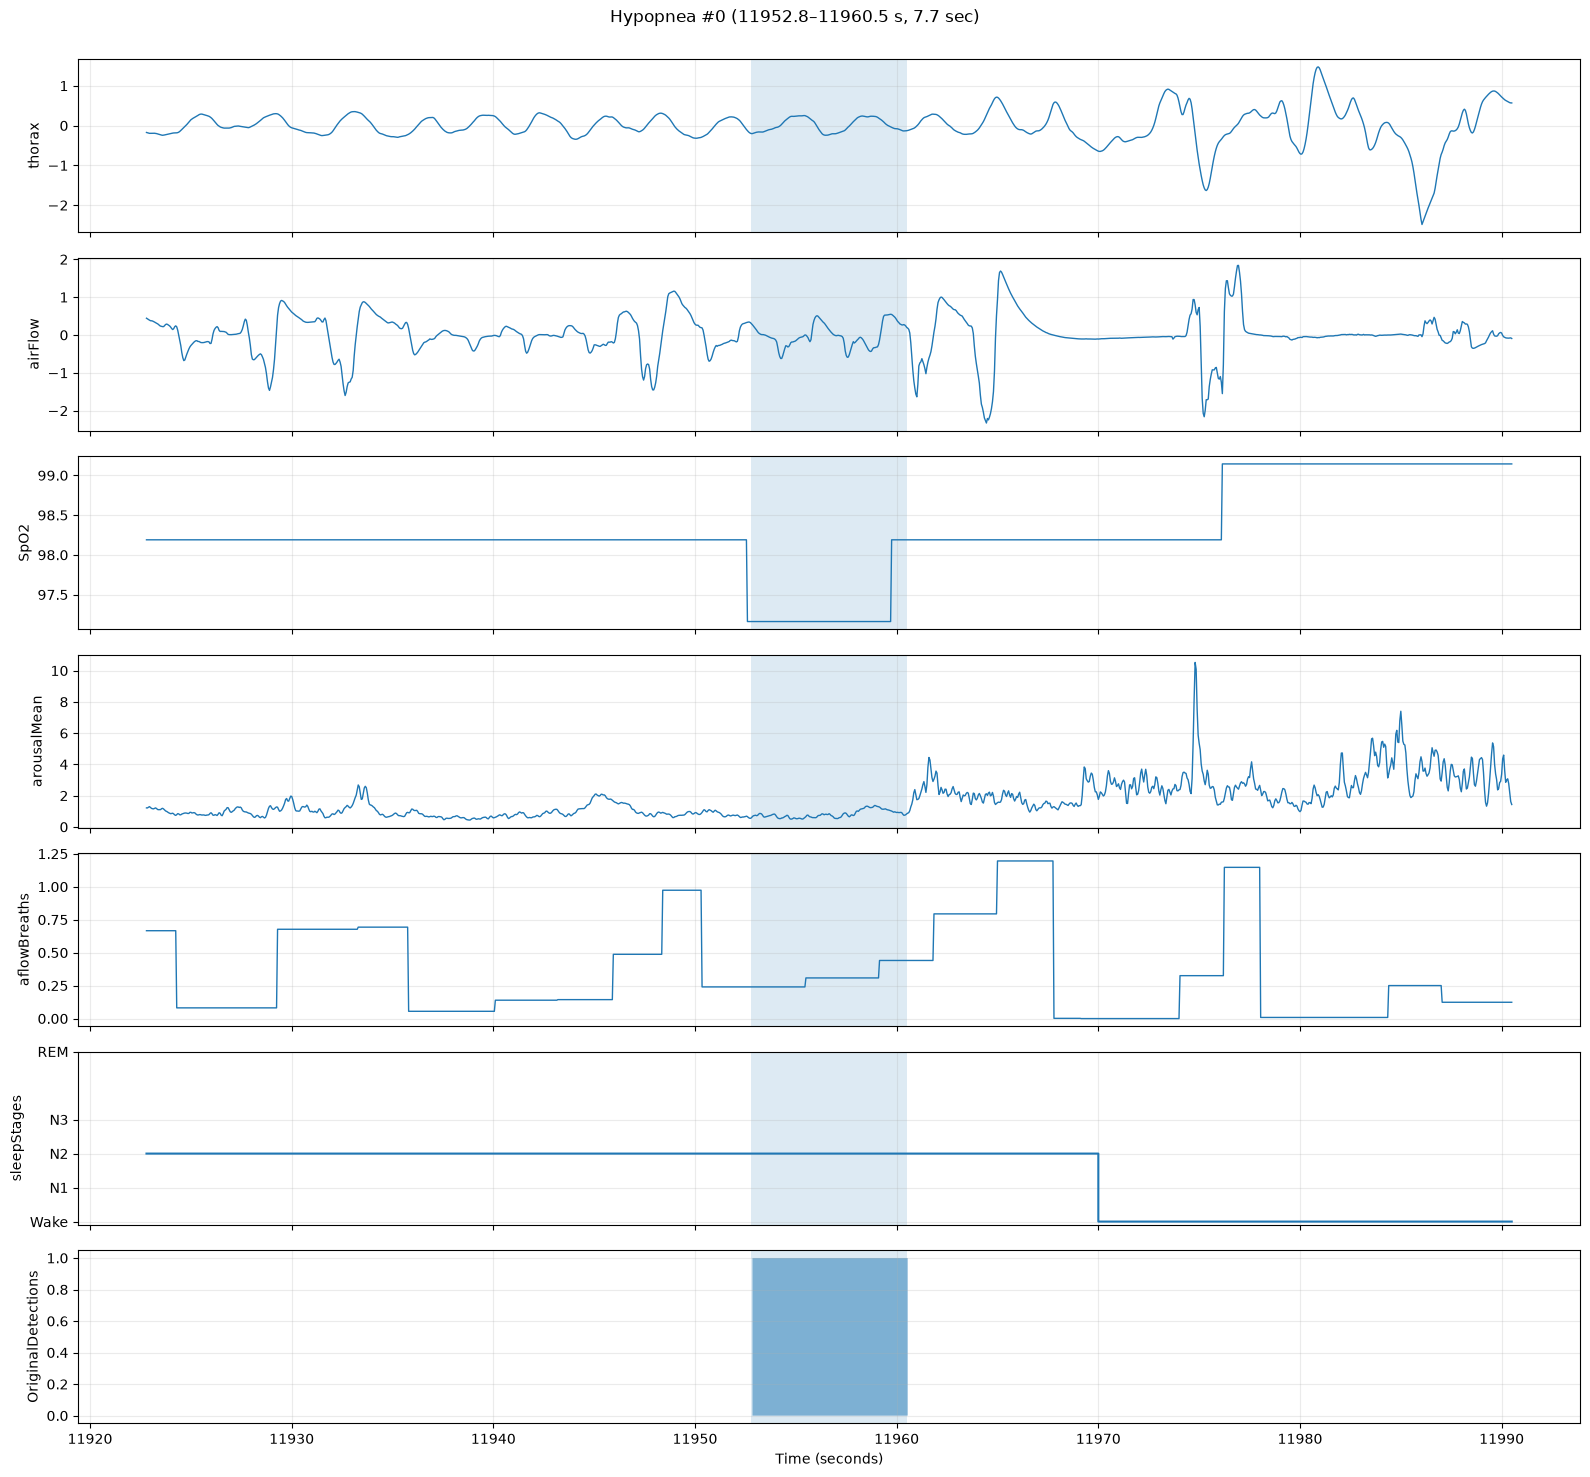

In [ ]:
plot_event(
    time,
    data,
    labels,
    hypopneas,
    event_number=0,
    padding_sec=30,
    event_name="Hypopnea"
)

In [ ]:
channels_to_plot = [
    "thorax",
    "airFlow",
    "SpO2",
    "aflowBreaths"
]
def plot_channels(
    time,
    data,
    labels,
    channels,
    start_sec,
    duration_sec
):

    label_to_idx = {label: i for i, label in enumerate(labels)}

    missing = [c for c in channels if c not in label_to_idx]
    if missing:
        raise ValueError(f"Missing channels: {missing}")

    end_sec = start_sec + duration_sec
    mask = (time >= start_sec) & (time <= end_sec)

    fig, axes = plt.subplots(
        len(channels),
        1,
        figsize=(16, 2.5 * len(channels)),
        sharex=True
    )

    if len(channels) == 1:
        axes = [axes]

    for ax, channel in zip(axes, channels):

        idx = label_to_idx[channel]

        ax.plot(
            time[mask],
            data[mask, idx],
            linewidth=1
        )

        ax.set_ylabel(channel)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("Time (seconds)")

    plt.tight_layout()
    plt.show()

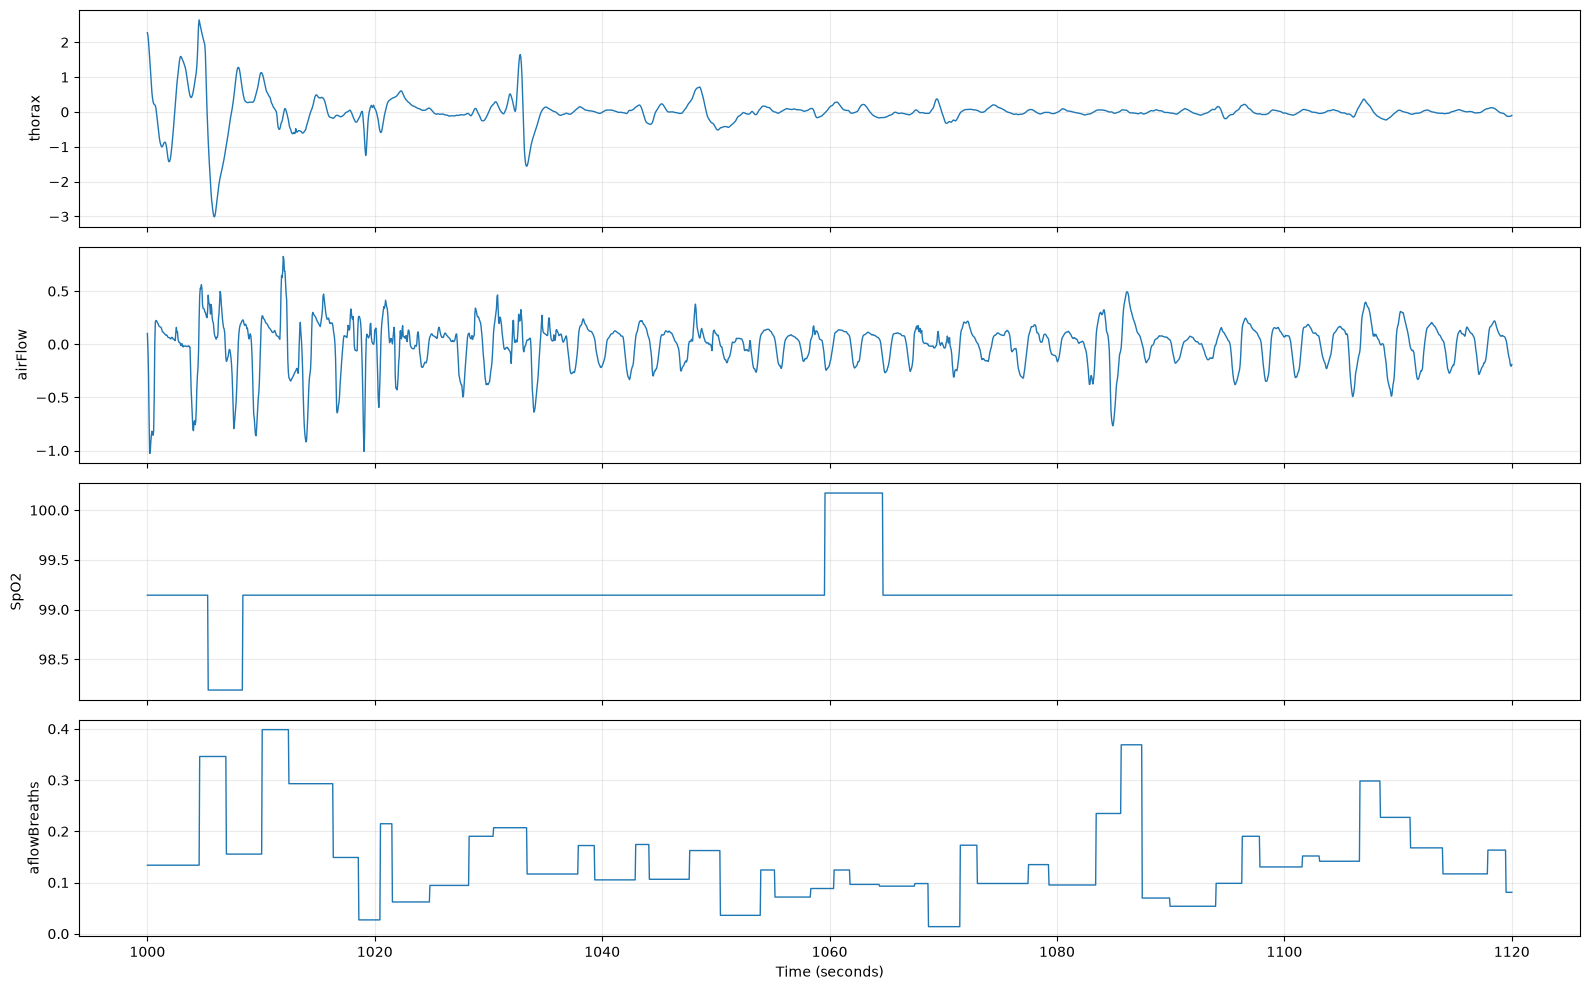

In [ ]:
plot_channels(
    time,
    data,
    labels,
    channels=[
        "thorax",
        "airFlow",
        "SpO2",
        "aflowBreaths"
    ],
    start_sec=1000,
    duration_sec=120
)